## Step 1: Kaggle Dataset Download

In [ ]:
from google.colab import files
files.upload()  # kaggle.json upload karein

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"kannuvarshney","key":"4c7516534caab9b10f1fd2ac9c943dd0"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d msambare/fer2013
!unzip -q fer2013.zip
print('Dataset ready!')

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100% 60.3M/60.3M [00:00<00:00, 128MB/s]

Dataset ready!


## Step 2: Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau,
    ModelCheckpoint, LearningRateScheduler
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
import math

print('TF version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TF version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 3: Config

In [ ]:
# ── Hyperparameters ────────────────────────────────────────────────
IMG_SIZE    = 48
BATCH_SIZE  = 64
EPOCHS      = 100
LR          = 0.001
NUM_CLASSES = 7

TRAIN_DIR = '/content/train'
TEST_DIR  = '/content/test'

EMOTION_LABELS = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']

print('Config set!')

Config set!


## Step 4: Preprocessing

In [ ]:
def preprocess_img(img):
    """CLAHE enhancement + normalization."""
    img = img.squeeze().astype('uint8')
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)
    img = img / 255.0
    return np.expand_dims(img, axis=-1)


def cutout(img, n_holes=1, length=10):
    """Randomly mask square patches — improves generalization."""
    h, w = img.shape[:2]
    mask = np.ones((h, w), np.float32)
    for _ in range(n_holes):
        cx = np.random.randint(w)
        cy = np.random.randint(h)
        x1, x2 = max(0, cx - length // 2), min(w, cx + length // 2)
        y1, y2 = max(0, cy - length // 2), min(h, cy + length // 2)
        mask[y1:y2, x1:x2] = 0.0
    return img * mask[..., np.newaxis]


def preprocess_with_cutout(img):
    """CLAHE + normalize + random cutout (training only)."""
    img = preprocess_img(img)
    if np.random.rand() < 0.5:          # 50% chance
        img = cutout(img, n_holes=1, length=12)
    return img

print('Preprocessing functions defined!')

Preprocessing functions defined!


## Step 5: Data Generators

In [ ]:
# ── Training generator (heavy augmentation) ────────────────────────
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_with_cutout,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    fill_mode='nearest',
    validation_split=0.1        # only 10% for val — more data to train on
)

# ── Val / Test generators (only CLAHE normalize) ───────────────────
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_img)

train_data = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

test_data = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f'Train: {train_data.samples} | Val: {val_data.samples} | Test: {test_data.samples}')

Found 25841 images belonging to 7 classes.
Found 2868 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Train: 25841 | Val: 2868 | Test: 7178


## Step 6: Class Weights (imbalanced FER-2013 fix)

In [ ]:
classes = train_data.classes
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)
class_weights = dict(enumerate(class_weights_arr))

for i, w in class_weights.items():
    print(f'  {EMOTION_LABELS[i]:10s}: {w:.3f}')

  Angry     : 1.027
  Disgust   : 9.393
  Fear      : 1.001
  Happy     : 0.568
  Neutral   : 0.826
  Sad       : 0.849
  Surprise  : 1.293


## Step 7: Model Architecture
**Deeper CNN with double conv blocks + residual-style skip connections**

In [ ]:
def build_model(input_shape=(48, 48, 1), num_classes=7):
    """
    Deep CNN for FER-2013.
    Architecture: 4 Conv blocks → GAP → Dense head
    """
    inp = keras.Input(shape=input_shape)

    # ── Block 1: 64 filters ─────────────────────────────────────────
    x = layers.Conv2D(64, (3,3), padding='same', use_bias=False)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2, 2)(x)
    x = layers.Dropout(0.25)(x)

    # ── Block 2: 128 filters ────────────────────────────────────────
    x = layers.Conv2D(128, (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2, 2)(x)
    x = layers.Dropout(0.25)(x)

    # ── Block 3: 256 filters ────────────────────────────────────────
    x = layers.Conv2D(256, (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(256, (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2, 2)(x)
    x = layers.Dropout(0.3)(x)

    # ── Block 4: 512 filters ────────────────────────────────────────
    x = layers.Conv2D(512, (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2, 2)(x)
    x = layers.Dropout(0.3)(x)

    # ── Classifier Head ─────────────────────────────────────────────
    x = layers.GlobalAveragePooling2D()(x)  # GAP instead of Flatten — fewer params  # GAP instead of Flatten — fewer params
    x = layers.Dense(512, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(256, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)

    out = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inp, out, name='FaceEmotionCNN')
    return model


model = build_model()
model.summary()

Model: "FaceEmotionCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 48, 48, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 48, 48, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 24, 24, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 24, 24, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 12, 12, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_25 (Activation)      │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 12, 12, 256)    │       589,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 2,726,727 (10.40 MB)

 Trainable params: 2,722,375 (10.39 MB)

 Non-trainable params: 4,352 (17.00 KB)

## Step 8: Compile with Label Smoothing

In [ ]:
# Label smoothing — prevents overconfidence, improves generalization
model.compile(
    optimizer=Adam(learning_rate=LR),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)
print('Model compiled!')

Model compiled!


## Step 9: Callbacks

In [ ]:
# ── Cosine Annealing LR Schedule ──────────────────────────────────
def cosine_annealing(epoch, lr):
    """Cosine decay: LR smoothly reduces each epoch."""
    min_lr   = 1e-6
    max_lr   = LR
    T_max    = EPOCHS
    new_lr   = min_lr + 0.5 * (max_lr - min_lr) * (1 + math.cos(math.pi * epoch / T_max))
    return float(new_lr)


callbacks = [
    # Save best model
    ModelCheckpoint(
        'best_face_emotion_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    # Early stopping with longer patience
    EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    # Cosine LR schedule
    LearningRateScheduler(cosine_annealing, verbose=0),
]

print('Callbacks ready!')

Callbacks ready!


## Step 10: Train

In [ ]:
steps_per_epoch  = train_data.samples  // BATCH_SIZE
validation_steps = val_data.samples   // BATCH_SIZE

print(f'Steps/epoch: {steps_per_epoch} | Val steps: {validation_steps}')
print('Training shuru ho rahi hai...')

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks,
    class_weight=class_weights
)

Steps/epoch: 403 | Val steps: 44
Training shuru ho rahi hai...
Epoch 1/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.1566 - loss: 2.2837
Epoch 1: val_accuracy improved from None to 0.13033, saving model to best_face_emotion_model.keras

Epoch 1: finished saving model to best_face_emotion_model.keras
403/403 ━━━━━━━━━━━━━━━━━━━━ 66s 114ms/step - accuracy: 0.1618 - loss: 2.1457 - val_accuracy: 0.1303 - val_loss: 2.1368 - learning_rate: 0.0010
Epoch 2/100
  1/403 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.1719 - loss: 2.1823

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.13033 to 0.13246, saving model to best_face_emotion_model.keras

Epoch 2: finished saving model to best_face_emotion_model.keras
403/403 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1719 - loss: 2.1823 - val_accuracy: 0.1325 - val_loss: 2.1377 - learning_rate: 9.9975e-04
Epoch 3/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.1776 - loss: 1.9923
Epoch 3: val_accuracy did not improve from 0.13246
403/403 ━━━━━━━━━━━━━━━━━━━━ 34s 85ms/step - accuracy: 0.1841 - loss: 1.9664 - val_accuracy: 0.0994 - val_loss: 2.4076 - learning_rate: 9.9901e-04
Epoch 4/100
  1/403 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.1250 - loss: 1.9497
Epoch 4: val_accuracy did not improve from 0.13246
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.1250 - loss: 1.9497 - val_accuracy: 0.0966 - val_loss: 2.5515 - learning_rate: 9.9778e-04
Epoch 5/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.2221 - loss: 1.9158
Epoch 5: val_accuracy improv

## Step 11: Load Best Model & Evaluate

In [ ]:
# Load best saved weights
model = keras.models.load_model('best_face_emotion_model.keras')

loss, acc = model.evaluate(test_data, verbose=1)
print(f'\n✅ Test Loss    : {loss:.4f}')
print(f'✅ Test Accuracy : {acc*100:.2f}%')

113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.6279 - loss: 1.1957

✅ Test Loss    : 1.1957
✅ Test Accuracy : 62.79%


## Step 12: Training Curves

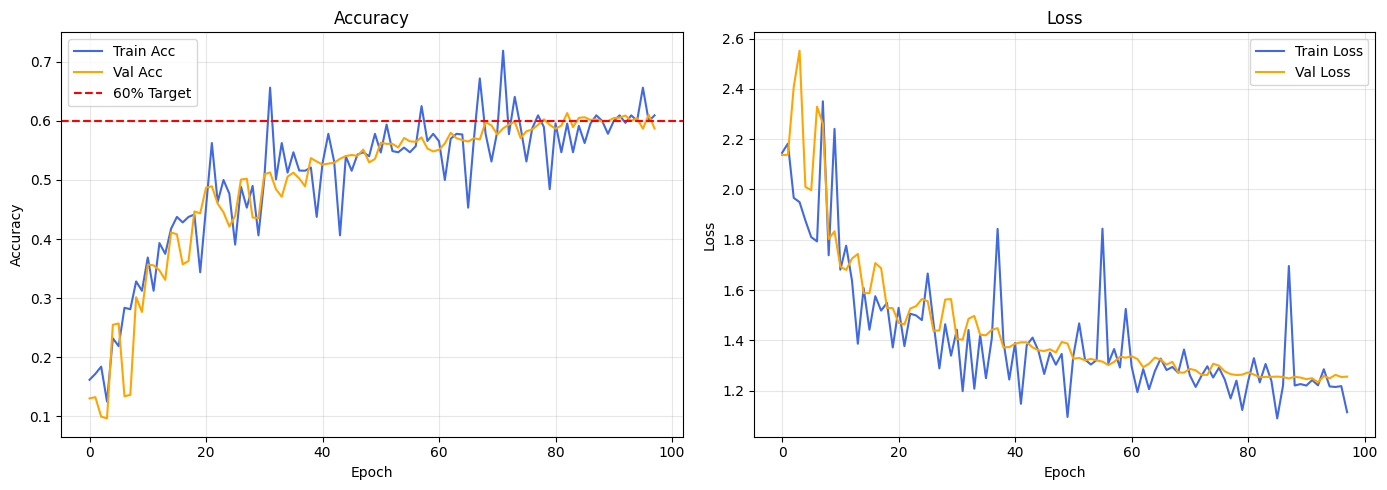

Graph save ho gaya!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Acc',  color='royalblue')
axes[0].plot(history.history['val_accuracy'], label='Val Acc',    color='orange')
axes[0].axhline(0.60, color='red', linestyle='--', label='60% Target')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss', color='royalblue')
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='orange')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print('Graph save ho gaya!')

## Step 13: Per-Class Accuracy (Confusion Matrix)

113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step

📊 Classification Report:
              precision    recall  f1-score   support

       Angry       0.53      0.57      0.55       958
     Disgust       0.38      0.71      0.50       111
        Fear       0.53      0.33      0.41      1024
       Happy       0.88      0.83      0.85      1774
     Neutral       0.51      0.70      0.59      1233
         Sad       0.54      0.43      0.48      1247
    Surprise       0.70      0.82      0.75       831

    accuracy                           0.63      7178
   macro avg       0.58      0.63      0.59      7178
weighted avg       0.63      0.63      0.62      7178



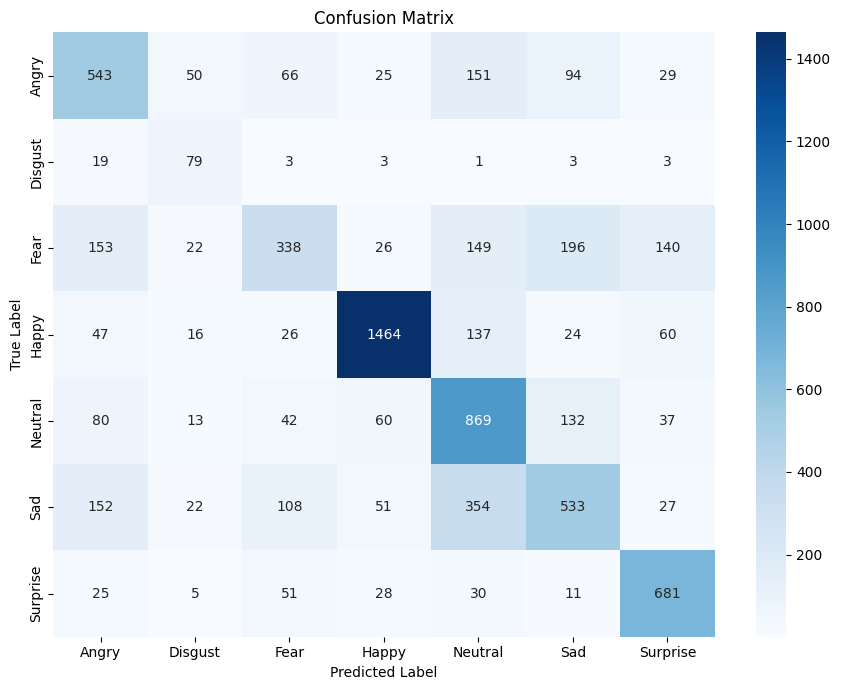

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

test_data.reset()
y_pred = model.predict(test_data, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true         = test_data.classes

print('\n📊 Classification Report:')
print(classification_report(y_true, y_pred_classes, target_names=EMOTION_LABELS))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=EMOTION_LABELS,
    yticklabels=EMOTION_LABELS,
    cmap='Blues'
)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## Step 14: Save & Download

In [ ]:
model.save('face_emotion_model.h5')
model.save('face_emotion_model.keras')
print('Models saved!')

from google.colab import files
files.download('face_emotion_model.keras')
files.download('face_emotion_model.h5')
files.download('training_curves.png')
files.download('confusion_matrix.png')

Models saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>